In [99]:
import easyvvuq as uq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [100]:
# number of inputs
d = 3

In [101]:
RESULTS_DIR = "run_results/"
with open(f"{RESULTS_DIR}vary", "rb") as f:
    vary = pickle.load(f)

sampler = uq.sampling.SCSampler(vary=vary, polynomial_order=1, quadrature_rule='C', sparse=True,
                                growth=True, dimension_adaptive=True)
sampler.load_state(f"{RESULTS_DIR}sampler")

with open(f"{RESULTS_DIR}QOI", "rb") as f:
    qoi_cols = pickle.load(f)

analysis = uq.analysis.SCAnalysis(sampler=sampler, qoi_cols=qoi_cols)
analysis.load_state(f"{RESULTS_DIR}analisys")

data_frame_ = pd.read_pickle(f"{RESULTS_DIR}data_frame")
data_frame = data_frame_.dropna()
results = analysis.analyse(data_frame)

In [102]:
data_frame

,run_id,iteration,BSIZE_X,BSIZE_Y,POWER_CAP,f
,0,0,0,0,0,0
0,1,0,4,4,226,1313.076763
1,2,0,4,4,253,1315.505487
2,3,0,4,4,198,1313.385404
3,4,0,1,4,226,782.817014
5,6,0,4,1,226,1244.522409
8,9,0,4,2,226,1316.994818
10,11,0,1,8,226,374.985470
11,12,0,2,4,226,1272.387237
12,13,0,8,1,226,1317.084621


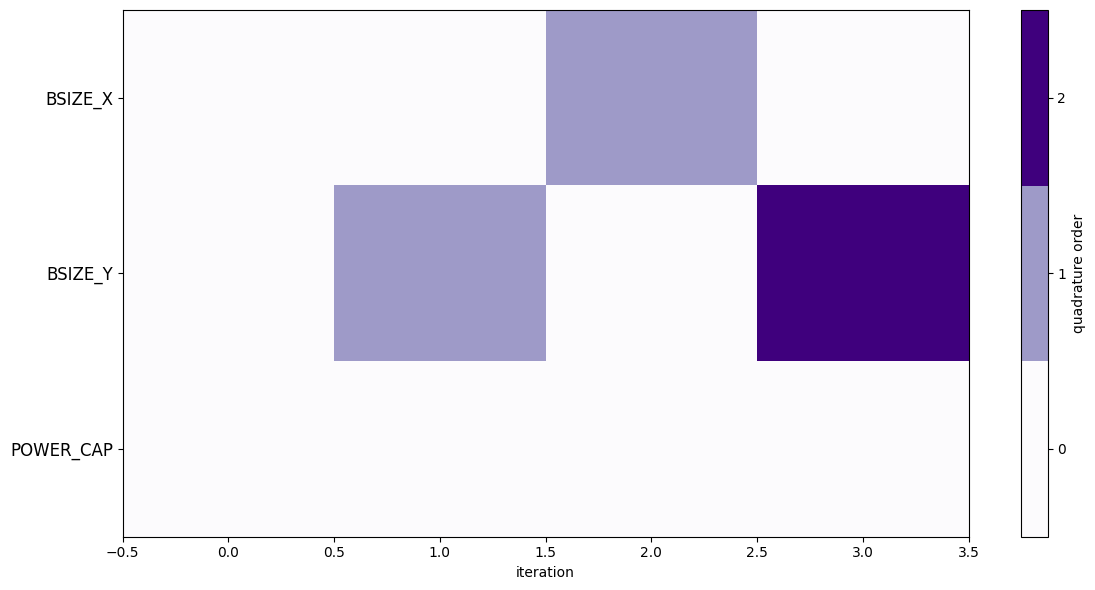

In [103]:
%matplotlib inline

# with plt.xkcd():
analysis.adaptation_table()

In [104]:
print(analysis.get_adaptation_errors())

[nan, nan, nan]


In [105]:
[analysis.get_pce_sobol_indices(QOI) for QOI in qoi_cols]

[(array([nan]),
  array([nan]),
  {(0,): array([nan]), (1,): array([nan]), (2,): array([0.])},
  {(0,): array([nan]), (1,): array([nan]), (2,): array([nan])})]

In [106]:
def get_confidence_intervals(samples, conf=0.9):
    """
    Compute the confidence intervals given an array of samples

    Parameters
    ----------
    samples : array
        Samples on which to compute the intervals.
    conf : float, optional, must be in [0, 1].
        The confidence interval percentage. The default is 0.9.

    Returns
    -------
    lower : array
        The lower confidence bound..
    upper : array
        The upper confidence bound.

    """

    # ake sure conf is in [0, 1]
    if conf < 0.0 or conf > 1.0:
        print('conf must be specified within [0, 1]')
        return

    # lower bound = alpha, upper bound = 1 - alpha
    alpha = 0.5 * (1.0 - conf)

    # arrays for lower and upper bound of the interval
    n_samples = samples.shape[0]
    N_qoi = samples.shape[1]
    lower = np.zeros(N_qoi)
    upper = np.zeros(N_qoi)

    # the probabilities of the ecdf
    prob = np.linspace(0, 1, n_samples)
    # the closest locations in prob that correspond to the interval bounds
    idx0 = np.where(prob <= alpha)[0][-1]
    idx1 = np.where(prob <= 1.0 - alpha)[0][-1]

    # for every location of qoi compute the ecdf-based confidence interval
    for i in range(N_qoi):
        # the sorted surrogate samples at the current location
        samples_sorted = np.sort(samples[:, i])
        # the corresponding confidence interval
        lower[i] = samples_sorted[idx0]
        upper[i] = samples_sorted[idx1]

    return lower, upper

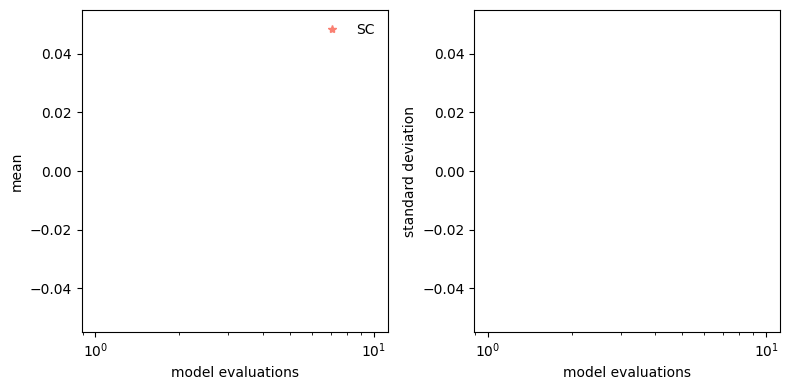

In [107]:

fig = plt.figure(figsize=[8,4])
ax = fig.add_subplot(121, xscale='log', xlabel='model evaluations', ylabel='mean')
ax.plot(np.cumsum(sampler.n_new_points), analysis.mean_history, '*', color='salmon', zorder=3, label='SC')
plt.legend(frameon=False)
ax = fig.add_subplot(122, xscale='log', xlabel='model evaluations', ylabel='standard deviation')
ax.plot(np.cumsum(sampler.n_new_points), np.array(analysis.std_history)**0.5, '*', color='salmon', zorder=3)
plt.tight_layout()

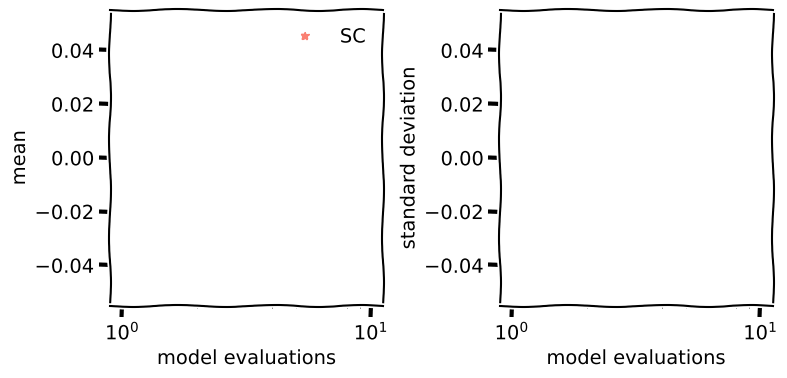

In [108]:
mean_SC = [results.describe(QOI, 'mean') for QOI in qoi_cols]
std_SC = [results.describe(QOI, 'std') for QOI in qoi_cols]

with plt.xkcd():
    fig = plt.figure(figsize=[8,4])
    ax = fig.add_subplot(121, xscale='log', xlabel='model evaluations', ylabel='mean')
    ax.plot(np.cumsum(sampler.n_new_points), analysis.mean_history, '*', color='salmon', zorder=3, label='SC')
    plt.legend(frameon=False)

    ax = fig.add_subplot(122, xscale='log', xlabel='model evaluations', ylabel='standard deviation')
    ax.plot(np.cumsum(sampler.n_new_points), np.array(analysis.std_history)**0.5, '*', color='salmon', zorder=3)
    plt.tight_layout()

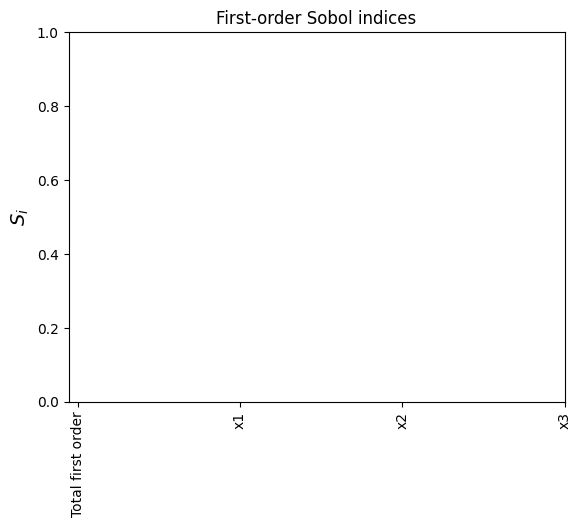

In [109]:
for QOI in qoi_cols:
    fig = plt.figure()
    ax = fig.add_subplot(111, title=r'First-order Sobol indices', ylim=[0,1])
    ax.set_ylabel(r'$S_i$', fontsize=14)
    sobols_first = np.array(list(results.sobols_first(QOI).values()))
    ax.bar(0, np.sum(sobols_first), color='salmon')
    ax.bar(np.arange(1, d+1), sobols_first.flatten(), color='dodgerblue')
    labels = ['Total first order']
    for i in range(d): labels.append('x%d' % (i+1))
    ax.set_xticks(np.arange(d+1))
    ax.set_xticklabels(labels, rotation=90)

[None]

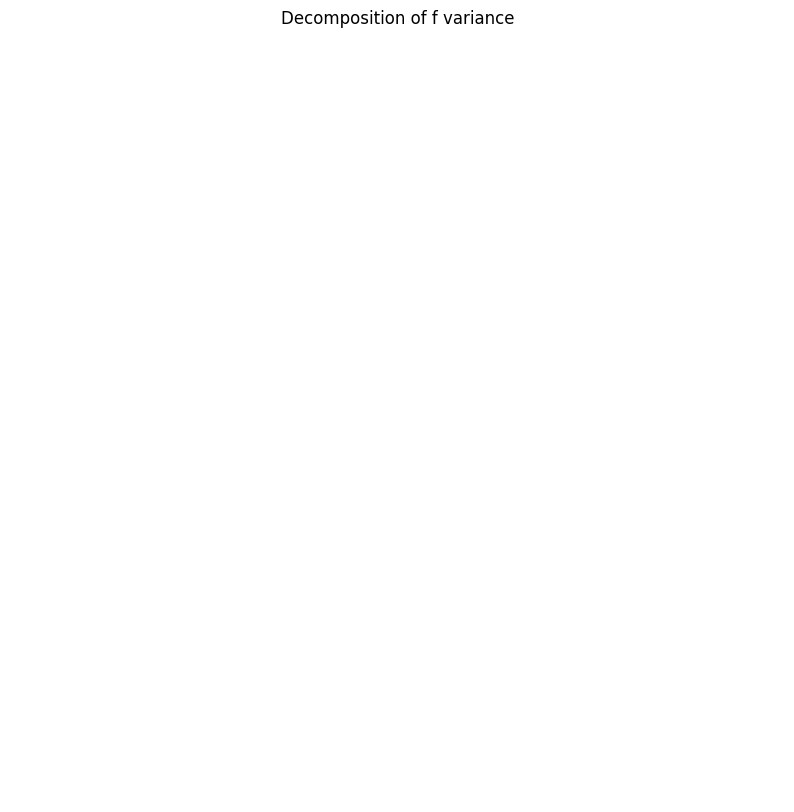

In [ ]:
invalid_data_frame